# Morocco WC2022: Defensive Efficiency & Attacking Precision
### Quantifying the Blueprint: How Morocco Reached the 2022 World Cup Semifinals
*Hachad Solutions LLC · March 2026 · StatsBomb Open Data*

## Motivation

Morocco became the first African and Arab nation to reach a World Cup  semifinal in 2022, eliminating Belgium, Spain, and Portugal along the way before falling to France. Post-tournament tactical analysis, the FIFA Technical Study Group report, and academic profiling work all highlighted a compact defensive structure, disciplined low-to-mid block, and effective transitions as the hallmarks of their run.

This project takes those observations as a starting point and interrogates them with StatsBomb event and 360 data  to see what the numbers actually say at the event level. All existing analysis used aggregated post-match report data. This project uses StatsBomb's event-level and 360 spatial data — a level of granularity no prior published analysis has applied to this specific question.

See `REFERENCES.md` for the prior work that informed this framing.

## Analytical Questions

This project asks three open questions; the answers will emerge from the data:

**Q1: Defensive structure:**  
What does Morocco's defensive behaviour actually look like at the event level across 7 matches? Where did they win the ball back, and what quality of chance did opponents generate as a result? Which individual players or spatial zones drove that structure?

**Q2: Attacking efficiency:**  
Was Morocco's attacking output a reflection of genuine chance quality, or did they outperform their xG? What do their goals look like spatially compared to their baseline expected threat?

**Q3: Broader applicability and WC2026 relevance:**
Can Morocco's WC2022 performance be characterised as a replicable blueprint rather than a one-off? Using Morocco's quantified defensive and offensive profile as a reference point, which qualified WC2026 nations share a similar competitive tier and could plausibly adopt a similar approach? This phase draws on additional data sources beyond StatsBomb to profile WC2026 participants and map them against Morocco's blueprint.

## Notebook Structure

1. Setup & Data Loading
2. Morocco Matches Overview
3. Defensive Analysis
   - 3a. Pressure & defensive intervention map
   - 3b. Opponent shot quality: location and xG
   - 3c. Individual contributions to defensive structure
4. Offensive Analysis
   - 4a. Morocco shot map and xG
   - 4b. Goals vs. xG baseline: finishing efficiency
5. Tournament-level Comparison (all 32 teams)
6. Findings & Conclusions

## Data Source

**StatsBomb Open Data: FIFA World Cup 2022**  
`competition_id = 43` · `season_id = 106`  
64 matches · 32 teams · Full event + 360 freeze-frame data  
https://github.com/statsbomb/open-data

*Data accessed via `statsbombpy` SDK. Per StatsBomb's user agreement, 
this project credits StatsBomb as the data source for all analysis 
derived from their data.*

---
## 1. Setup & Data Loading

In [1]:
# Data source
from statsbombpy import sb

# Data wrangling
import pandas as pd
import numpy as np

# Database
import sqlite3
from pathlib import Path
import ast

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from mplsoccer import Pitch, VerticalPitch

# FRMF / Morocco national team color palette
MOROCCO_RED   = '#E50011'
MOROCCO_GREEN = '#17A376'
MOROCCO_GOLD  = '#D29D63'
MOROCCO_WHITE = '#FFFFFF'
MOROCCO_DARK  = '#1a0a0a'

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
%matplotlib inline

### 1.1 Load Morocco Matches

In [2]:
# Load all WC2022 matches
matches = sb.matches(competition_id=43, season_id=106)

# Filter to Morocco matches only
morocco_matches = matches[
    (matches['home_team'] == 'Morocco') |
    (matches['away_team'] == 'Morocco')    
].reset_index(drop=True)

# Display Match Overview
morocco_matches[[
    'match_id', 'match_date', 'competition_stage', 'home_team', 'home_score', 'away_team', 'away_score'
]].sort_values('match_date')

,match_id,match_date,competition_stage,home_team,home_score,away_team,away_score
5,3857277,2022-11-23,Group Stage,Morocco,0,Croatia,0
4,3857283,2022-11-27,Group Stage,Belgium,0,Morocco,2
6,3857276,2022-12-01,Group Stage,Canada,1,Morocco,2
3,3869220,2022-12-06,Round of 16,Morocco,0,Spain,0
0,3869486,2022-12-10,Quarter-finals,Morocco,1,Portugal,0
2,3869552,2022-12-14,Semi-finals,France,2,Morocco,0
1,3869684,2022-12-17,3rd Place Final,Croatia,2,Morocco,1


### 1.2 Full Data Ingestion

In [3]:
# Fetch all events across all 7 Morocco matches
match_ids = morocco_matches['match_id'].tolist()

events_list = []
for mid in match_ids:
    print(f"Fetching events for match_id {mid}...")
    df = sb.events(match_id=mid)
    df['match_id'] = mid #to tag each row with its respective match
    events_list.append(df)

events_df = pd.concat(events_list, ignore_index=True)
print(f"\nTotal Events Loaded: {len(events_df):,}") #add commas as thousands separators
print(f"Number of Columns: {events_df.shape[1]}")

Fetching events for match_id 3869486...
Fetching events for match_id 3869684...
Fetching events for match_id 3869552...
Fetching events for match_id 3869220...
Fetching events for match_id 3857283...
Fetching events for match_id 3857277...
Fetching events for match_id 3857276...

Total Events Loaded: 25,971
Number of Columns: 105


In [4]:
# Fetch all 360 freeze-frame data across all 7 Morocco matches

frames_list = []
for mid in match_ids:
    print(f"Fetching 360 freeze frames for match_id: {mid}...")
    df = sb.frames(match_id=mid)
    df['match_id'] = mid
    frames_list.append(df)

frames_df = pd.concat(frames_list, ignore_index=True)
print(f"\nTotal Freeze Frames Loaded: {len(frames_df):,}")
print(f"Number of Columns: {frames_df.shape[1]}")

Fetching 360 freeze frames for match_id: 3869486...
Fetching 360 freeze frames for match_id: 3869684...
Fetching 360 freeze frames for match_id: 3869552...
Fetching 360 freeze frames for match_id: 3869220...
Fetching 360 freeze frames for match_id: 3857283...
Fetching 360 freeze frames for match_id: 3857277...
Fetching 360 freeze frames for match_id: 3857276...

Total Freeze Frames Loaded: 344,302
Number of Columns: 7


In [5]:
# Write to SQLite DB
db_path = Path('../data/processed/morocco.db')
db_path.parent.mkdir(parents=True, exist_ok=True) # ensures that directory structure exists so code doesn't crash when it tries to write the db

con = sqlite3.connect(db_path)

# Serialize any nested columns to JSON strings for SQLite compatibility
for col in events_df.columns:
    if events_df[col].dtype == object:
        events_df[col] = events_df[col].apply(
            lambda x: str(x) if isinstance(x, (list, dict)) else x
        )

for col in frames_df.columns:
    if frames_df[col].dtype == object:
        frames_df[col] = frames_df[col].apply(
            lambda x: str(x) if isinstance(x, (list, dict)) else x
        )

events_df.to_sql('events', con, if_exists='replace', index=False, method='multi', chunksize=100) # method = multi : instead of sending rows one by one (which is slow), it groups them into batches
frames_df.to_sql('frames', con, if_exists='replace', index=False, method='multi', chunksize=100)

# Verify row counts
events_count = pd.read_sql("SELECT COUNT(*) AS number_of_events FROM events", con).iloc[0,0] # iloc[0,0] converts the result from a table containing a number into just a raw integer
frames_count = pd.read_sql("SELECT COUNT(*) AS number_of_frames FROM frames", con).iloc[0,0]

In [6]:
# SQL inspection: event type breakdown
event_types = pd.read_sql("""
    SELECT type, COUNT(*) AS count
    FROM events
    GROUP BY type
    ORDER BY count DESC
    LIMIT 15
""", con)

print("\nTop 15 event types:")
event_types


Top 15 event types:


,type,count
0,Pass,7530
1,Ball Receipt*,6932
2,Carry,6094
3,Pressure,1968
4,Ball Recovery,642
5,Duel,450
6,Clearance,249
7,Block,227
8,Miscontrol,221
9,Dribble,214


--- 
## 2. Morocco Matches Overview

In [7]:
# Clean match summary table
# Identify Morocco's score and oppponent for each match
def get_morocco_summary(row):
    if row['home_team'] == 'Morocco':
        return pd.Series({
            'opponent': row['away_team'],
            'morocco_score': row['home_score'],
            'opponent_score': row['away_score'],
            'result': 'W' if row['home_score'] > row['away_score'] else ('D' if row['home_score'] == row['away_score'] else 'L')
        })
    else:
        return pd.Series({
            'opponent': row['home_team'],
            'morocco_score': row['away_score'],
            'opponent_score': row['home_score'],
            'result': 'W' if row['away_score'] > row['home_score'] else ('D' if row['away_score'] == row['home_score'] else 'L')
        })

summary_cols = morocco_matches[['match_id', 'match_date', 'competition_stage', 'home_team', 'home_score', 'away_team', 'away_score']].sort_values('match_date').copy()

extra = summary_cols.apply(get_morocco_summary, axis = 1) # axis=1 moves along axis 1 (the column axis) meaning it collapses columns and applies the function to each row.

match_summary = pd.concat([summary_cols[['match_id', 'match_date', 'competition_stage']].reset_index(drop=True), extra.reset_index(drop=True)], axis=1) # axis = 1 stacks DataFrames side by side (column-wise) rather than stacking them on top of each other.

match_summary

,match_id,match_date,competition_stage,opponent,morocco_score,opponent_score,result
0,3857277,2022-11-23,Group Stage,Croatia,0,0,D
1,3857283,2022-11-27,Group Stage,Belgium,2,0,W
2,3857276,2022-12-01,Group Stage,Canada,2,1,W
3,3869220,2022-12-06,Round of 16,Spain,0,0,D
4,3869486,2022-12-10,Quarter-finals,Portugal,1,0,W
5,3869552,2022-12-14,Semi-finals,France,0,2,L
6,3869684,2022-12-17,3rd Place Final,Croatia,1,2,L


In [8]:
# Persist match metadata for join capability
match_summary.to_sql('matches', con, if_exists='replace', index=False)

7

In [9]:
# Event counts per match: sanity check and overview

events_counts_per_match = pd.read_sql("""
    SELECT
        e.match_id,
        m.match_date,
        m.competition_stage,
        m.opponent,
        m.morocco_score,
        m.opponent_score,
        m.result,
        COUNT(*) AS total_events,
        SUM(CASE WHEN e.team = 'Morocco' THEN 1 ELSE 0 END) AS morocco_events,
        SUM(CASE WHEN e.team != 'Morocco' THEN 1 ELSE 0 END) AS opponent_events
    FROM events e
    JOIN matches m ON e.match_id = m.match_id
    GROUP BY e.match_id
    ORDER BY m.match_date
""", con)

events_counts_per_match

,match_id,match_date,competition_stage,opponent,morocco_score,opponent_score,result,total_events,morocco_events,opponent_events
0,3857277,2022-11-23,Group Stage,Croatia,0,0,D,3719,1498,2221
1,3857283,2022-11-27,Group Stage,Belgium,2,0,W,3621,1361,2260
2,3857276,2022-12-01,Group Stage,Canada,2,1,W,3389,1472,1917
3,3869220,2022-12-06,Round of 16,Spain,0,0,D,4750,1371,3379
4,3869486,2022-12-10,Quarter-finals,Portugal,1,0,W,3381,1111,2270
5,3869552,2022-12-14,Semi-finals,France,0,2,L,3551,2071,1480
6,3869684,2022-12-17,3rd Place Final,Croatia,1,2,L,3560,1798,1762


In [10]:
# Plotly visualization: Morocco vs. Opponent event counts per match
# [Plotly / interactive] - grouped bar chart, FRMF palette

ecpm = events_counts_per_match.copy()
#Build x-axis labels from the existing events_counts_per_match df
ecpm["match_label"] = (
    ecpm['opponent'] + '<br>'
    + ecpm['competition_stage'] + ' . '
    + ecpm['morocco_score'].astype(str)
    + '-'
    + ecpm['opponent_score'].astype(str)
    + ' (' + ecpm['result'] + ')'
)

# Build viz
fig = go.Figure()

fig.add_trace(go.Bar(
    name='Morocco',
    x=ecpm['match_label'],
    y=ecpm['morocco_events'],
    marker_color=MOROCCO_RED,
    hovertemplate='<b>Morocco</b><br>Events: %{y:,}<extra></extra>',
))

fig.add_trace(go.Bar(
    name='Opponent',
    x=ecpm['match_label'],
    y=ecpm['opponent_events'],
    marker_color=MOROCCO_GREEN,
    customdata=ecpm['opponent'],
    hovertemplate='<b>%{customdata}</b><br>Events: %{y:,}<extra></extra>',
))

fig.update_layout(
    barmode = 'group',
    title=dict(
        text='Event Volume per Match: Morocco vs. Opponent',
        font=dict(color=MOROCCO_WHITE, size=16)
    ),
    paper_bgcolor=MOROCCO_DARK,
    plot_bgcolor=MOROCCO_DARK,
    font=dict(color=MOROCCO_WHITE),
    legend=dict(
        bgcolor='rgba(0,0,0,0)',
        font=dict(color=MOROCCO_WHITE)
    ),
    xaxis=dict(
        tickfont=dict(size=11, color=MOROCCO_WHITE),
        gridcolor='rgba(255,255,255,0.08)',
        linecolor='rgba(255,255,255,0.2)'
    ),
    yaxis=dict(
        title=dict(
            text='Event Count',
            font=dict(color=MOROCCO_WHITE)
        ),
        gridcolor='rgba(255,255,255,0.08)',
        linecolor='rgba(255,255,255,0.2)',
    ),
    margin=dict(t=60, b=20, l=60, r=20),
    height=420
)

fig.show()

---
## 3. Defensive Analysis
### 3a. Pressure & Defensive Intervention Map

In [11]:
# Before anything, first inspect available column in events table (although already available in sb documentation, good to have directly here inline)
columns = pd.read_sql("SELECT * FROM events LIMIT 1", con).columns.tolist()
print('\n'.join(columns))

ball_receipt_outcome
ball_recovery_recovery_failure
block_deflection
carry_end_location
clearance_aerial_won
clearance_body_part
clearance_head
clearance_left_foot
clearance_other
clearance_right_foot
counterpress
dribble_nutmeg
dribble_outcome
dribble_overrun
duel_outcome
duel_type
duration
foul_committed_advantage
foul_committed_card
foul_committed_offensive
foul_committed_type
foul_won_advantage
foul_won_defensive
goalkeeper_body_part
goalkeeper_end_location
goalkeeper_outcome
goalkeeper_position
goalkeeper_punched_out
goalkeeper_technique
goalkeeper_type
id
index
injury_stoppage_in_chain
interception_outcome
location
match_id
minute
miscontrol_aerial_won
off_camera
out
pass_aerial_won
pass_angle
pass_assisted_shot_id
pass_body_part
pass_cross
pass_cut_back
pass_deflected
pass_end_location
pass_goal_assist
pass_height
pass_inswinging
pass_length
pass_outcome
pass_outswinging
pass_recipient
pass_recipient_id
pass_shot_assist
pass_switch
pass_technique
pass_through_ball
pass_type
peri

In [12]:
# Helper function: parse serialized location string back to x,y coordinates
def parse_coords(loc):
    try:
        coords = ast.literal_eval(loc) # parses a string that looks like a Python literal ("[34.2, 45.6]") and evaluates it back into the actual Python object ([34.2, 45.6])
        return coords[0], coords[1]
    except:
        return None, None
    
# Pull Morocco's defensive actions from DB with match context
morocco_defensive = pd.read_sql("""
    SELECT
        e.id,
        e.match_id,
        e.type,
        e.player,
        e.position,
        e.location,
        e.minute,
        e.period,
        e.duration,
        e.under_pressure,
        e.counterpress,
        e.play_pattern,
        e.interception_outcome,
        e.block_save_block,
        e.block_offensive,
        e.clearance_aerial_won,
        e.clearance_body_part,
        e.ball_recovery_offensive,
        e.duel_type,
        e.duel_outcome,
        m.opponent,
        m.competition_stage,
        m.result
    FROM events e
    JOIN matches m ON e.match_id = m.match_id
    WHERE e.team = 'Morocco'
      AND (
          e.type IN ('Pressure', 'Interception', 'Block', 'Clearance', 'Ball Recovery')
          OR (e.type = 'Duel' AND e.duel_type = 'Tackle')
      )
""", con)

# Parse x, y from location string
morocco_defensive[['x', 'y']] = morocco_defensive['location'].apply(
    lambda loc: pd.Series(parse_coords(loc))
)

print(f"Morocco defensive actions: {len(morocco_defensive):,}")
print(f"\nBy type:")
print(morocco_defensive['type'].value_counts().to_string())
print(f"\nBy match:")
print(morocco_defensive.groupby('match_id')['type'].count()
      .reset_index()
      .rename(columns={'type': 'defensive_actions'})
      .merge(match_summary[['match_id', 'match_date', 'opponent', 'competition_stage', 'result']], on ='match_id')
      .sort_values('match_date')
      .to_string(index=False))

Morocco defensive actions: 1,945

By type:
Pressure         1085
Ball Recovery     329
Clearance         171
Duel              137
Block             134
Interception       89

By match:
 match_id  defensive_actions match_date opponent competition_stage result
  3857277                306 2022-11-23  Croatia       Group Stage      D
  3857283                272 2022-11-27  Belgium       Group Stage      W
  3857276                278 2022-12-01   Canada       Group Stage      W
  3869220                328 2022-12-06    Spain       Round of 16      D
  3869486                300 2022-12-10 Portugal    Quarter-finals      W
  3869552                216 2022-12-14   France       Semi-finals      L
  3869684                245 2022-12-17  Croatia   3rd Place Final      L


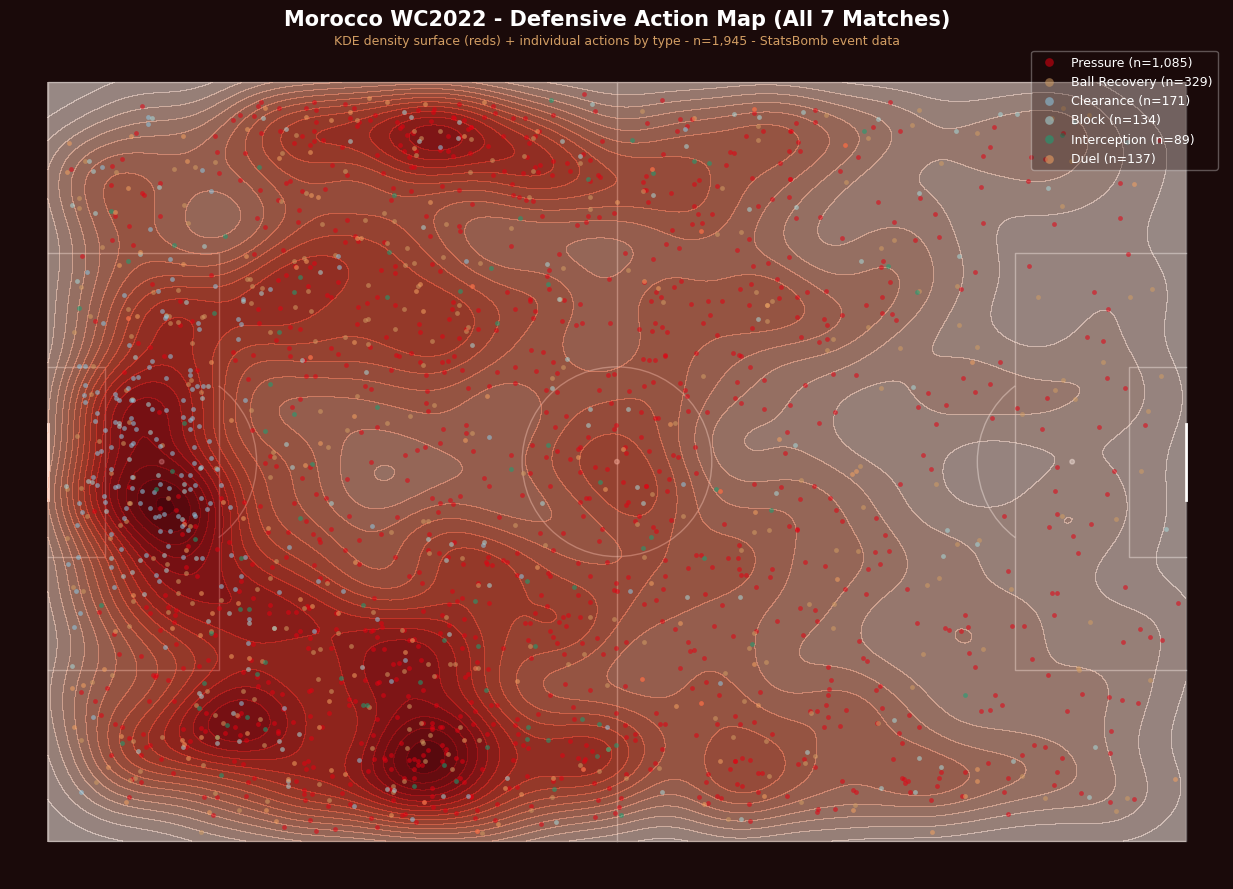

Saved: reports/figures/3a_defensive_map.png


In [13]:
# [mplsoccer / static] - KDE heatmap + scatter overlay

from scipy.stats import gaussian_kde

# Filter to rows with valid coordinates only (None = off-camera / substitutions / mostly administrative or transitional events; not typically defensive actions)
defensive_spatial = morocco_defensive.dropna(subset=['x', 'y']).copy()

# Color map per action type
type_colors = {
    'Pressure': MOROCCO_RED,
    'Ball Recovery': MOROCCO_GOLD,
    'Clearance': '#8ecae6',
    'Block': '#a8dadc',
    'Interception': MOROCCO_GREEN,
    'Duel': '#f4a261',
}

# Build pitch
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color=MOROCCO_DARK,
    line_color='#ffffff',
    line_alpha=0.4,
    linewidth=1,
)

fig, ax = pitch.draw(figsize=(14,9))
fig.patch.set_facecolor(MOROCCO_DARK)

# --- KDE heatmap layer ---

# scipy gaussian_kde operated on (2,N) array: rows=dimensions, cols=observations
x = defensive_spatial['x'].values #.values to get plain numpy array from pd series
y = defensive_spatial['y'].values

kde = gaussian_kde(np.vstack([x, y]), bw_method=0.15) #bandwidth method controls how wide each kernel bump is (for a given position, what radius of influence does that point have)
# Build meshgrid over StatsBomb pitch dimensions (120 x 80)
x_grid, y_grid = np.meshgrid(
    np.linspace(0, 120, 300),
    np.linspace(0, 80, 300)
)
z = kde(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)

ax.contourf(
    x_grid, y_grid, z,
    levels = 20,
    cmap='Reds',
    alpha=0.55,
    zorder=1
)

# --- Scatter overlay layer - one scatter per action type ---
for action_type, color in type_colors.items():
    subset = defensive_spatial[defensive_spatial['type'] == action_type]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset['x'],
        subset['y'],
        c=color,
        s=12,
        alpha=0.55,
        linewidths=0,
        label=f'{action_type} (n={len(subset):,})',
        zorder=2
    )

# --- Legend ---
legend = ax.legend(
    loc='upper right',
    fontsize=9,
    framealpha=0.3,
    facecolor=MOROCCO_DARK,
    edgecolor='#ffffff',
    labelcolor=MOROCCO_WHITE,
    markerscale=1.8,
)

# --- Title & Subtitle ---
ax.set_title(
    'Morocco WC2022 - Defensive Action Map (All 7 Matches)',
    color=MOROCCO_WHITE,
    fontsize=15,
    fontweight='bold',
    pad=14
)
ax.text(
    0.5, 1.0,
    'KDE density surface (reds) + individual actions by type - n=1,945 - StatsBomb event data',
    transform=ax.transAxes,
    ha='center',
    fontsize=9,
    color=MOROCCO_GOLD,
)

plt.tight_layout()

# --- Export ---
import os

os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(
    '../reports/figures/3a_defensive_map.png',
    dpi=180,
    bbox_inches='tight',
    facecolor=MOROCCO_DARK
)

plt.show()
print("Saved: reports/figures/3a_defensive_map.png")


### Section 3b - Opponent Shot Quality Map

Opponent Shots Against Morocco: 73
Total xG Conceded by Morocco: 9.0294202952
Goals Conceded by Morocco: 4
Save Rate: 17.8%
Off T      27
Blocked    22
Saved      13
Post        5
Goal        4
Wayward     2

xG Conceded per Match:
opponent competition_stage  shots  xg_conceded  goals_conceded
 Croatia       Group Stage      5     0.849861               0
 Belgium       Group Stage     10     0.642612               0
  Canada       Group Stage      5     1.095618               0
   Spain       Round of 16     15     2.845491               0
Portugal    Quarter-finals     12     0.744121               0
  France       Semi-finals     14     2.002449               2
 Croatia   3rd Place Final     12     0.849269               2


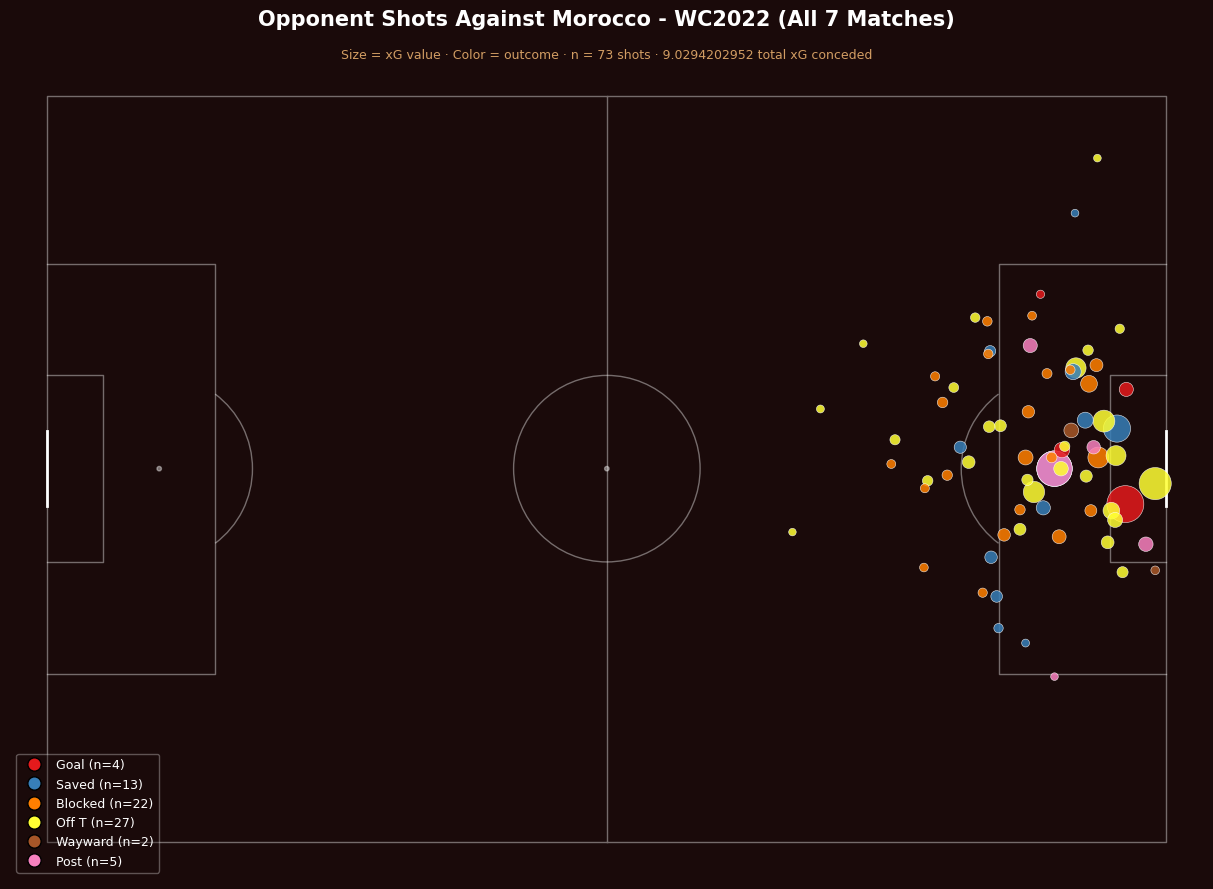

Saved: reports/figures/3b_opponent_shot_map.png
<class 'matplotlib.axes._axes.Axes'>


In [14]:
# [mplsoccer / static] - scatter: position = shot location, size = xG, color = shot outcome

# Query all opponent shots against Morocco from DB

opponent_shots = pd.read_sql("""
                        SELECT
                             e.id, 
                             e.match_id,
                             e.player,
                             e.team,
                             e.location,
                             e.minute,
                             e.period,
                             e.shot_statsbomb_xg,
                             e.shot_outcome,
                             e.shot_type,
                             e.shot_body_part,
                             e.shot_technique,
                             m.opponent,
                             m.competition_stage, 
                             m.result,
                             m.match_date
                        FROM events e
                        JOIN matches m ON e.match_id = m.match_id
                        WHERE e.type = 'Shot'
                        AND e.team != 'Morocco'
                             """, con)

# Parse coordinates
opponent_shots[['x', 'y']] = opponent_shots['location'].apply(
    lambda loc: pd.Series(parse_coords(loc))
)
opponent_shots = opponent_shots.dropna(subset=['x', 'y', 'shot_statsbomb_xg'])
opponent_shots = opponent_shots.sort_values('shot_statsbomb_xg', ascending=False)

# Summary stats
total_shots = len(opponent_shots)
total_xg_conceded = opponent_shots['shot_statsbomb_xg'].sum()
goals_conceded = len(opponent_shots[opponent_shots['shot_outcome'] == 'Goal'])

print(f"Opponent Shots Against Morocco: {total_shots}")
print(f"Total xG Conceded by Morocco: {total_xg_conceded}")
print(f"Goals Conceded by Morocco: {goals_conceded}")
print(f"Save Rate: {len(opponent_shots[opponent_shots['shot_outcome'].isin(['Saved', 'Saved Off Target', 'Saved To Post'])]) / total_shots:.1%}")
print(opponent_shots['shot_outcome'].value_counts().to_string())

print("\nxG Conceded per Match:")
xg_per_match = (opponent_shots
                .groupby('match_id')
                .agg(
                    shots=('shot_statsbomb_xg', 'count'),
                    xg_conceded=('shot_statsbomb_xg', 'sum'),
                    goals_conceded=('shot_outcome', lambda x: (x=='Goal').sum())
                )
                .reset_index()
                .merge(match_summary[['match_id', 'match_date', 'opponent', 'competition_stage']], on='match_id')
                .sort_values('match_date')
                )
print(xg_per_match[['opponent', 'competition_stage', 'shots', 'xg_conceded', 'goals_conceded']].to_string(index=False))

# Shot Map Creation

    # Outcome color palette

OUTCOME_COLORS = {
    'Goal': '#e41a1c',
    'Saved': '#377eb8',
    'Saved Off Target': '#4daf4a',
    'Saved To Post': '#984ea3',
    'Blocked': '#ff7f00',
    'Off T': '#ffff33',
    'Wayward': '#a65628',
    'Post': '#f781bf', 
}

pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color=MOROCCO_DARK,
    line_color='#ffffff',
    line_alpha=0.4,
    linewidth=1,   
)

fig, ax = pitch.draw(figsize=(14,9))
fig.patch.set_facecolor(MOROCCO_DARK)

    # Build color array from outcome mapping

shot_colors = opponent_shots['shot_outcome'].map(OUTCOME_COLORS).fillna('#cccccc')

ax.scatter(
    opponent_shots['x'],
    opponent_shots['y'],
    c=shot_colors,
    s=opponent_shots['shot_statsbomb_xg'] * 800 + 25,
    edgecolors='white',
    linewidth=0.4,
    alpha=0.86,
    zorder=3,
)

    # Legend

legend_handles = []

for outcome, color in OUTCOME_COLORS.items():
    count = (opponent_shots['shot_outcome'] == outcome).sum()
    if count > 0:
        legend_handles.append(
            plt.Line2D([0], [0], marker='o', color='none', markerfacecolor=color, markersize=16, label=f"{outcome} (n={count})")
        )

ax.legend(
    handles=legend_handles,
    loc='lower left',
    fontsize=9,
    framealpha=0.3,
    facecolor=MOROCCO_DARK,
    edgecolor='#ffffff',
    labelcolor=MOROCCO_WHITE,
    markerscale=0.6,
)

    # Title and subtitle

ax.set_title(
    'Opponent Shots Against Morocco - WC2022 (All 7 Matches)',
    color=MOROCCO_WHITE,
    fontsize=15,
    fontweight='bold',
    pad=24,
)
ax.text(
    0.5, 1.0,
    f'Size = xG value · Color = outcome · n = {total_shots} shots · {total_xg_conceded} total xG conceded',
    transform=ax.transAxes,
    ha='center',
    fontsize=9,
    color=MOROCCO_GOLD,
)

plt.tight_layout()

plt.savefig(
    '../reports/figures/3b_opponent_shot_map.png',
    dpi=180,
    bbox_inches='tight',
    facecolor=MOROCCO_DARK,
)

plt.show()
print('Saved: reports/figures/3b_opponent_shot_map.png')
print(type(ax))

In [23]:
# Section 3b — Plotly exploration: opponent shot map with hover tooltips
# This cell is exploratory — evaluate output quality vs. mplsoccer version above

import plotly.graph_objects as go

# ── Pitch layout as Plotly shapes (StatsBomb coords: 120 x 80) ──
pitch_shapes = [
    # Pitch outline
    dict(type='rect', x0=0, y0=60, x1=80, y1=120, line=dict(color='white', width=1)),
    # 18-yard box
    dict(type='rect', x0=18, y0=102, x1=62, y1=120, line=dict(color='white', width=1)),
    # 6-yard box
    dict(type='rect', x0=30, y0=114, x1=50, y1=120, line=dict(color='white', width=1)),
    # Penalty spot circle
    dict(type='circle', x0=39.7, y0=107.7, x1=40.3, y1=108.3, line=dict(color='white', width=1), fillcolor='white'),
    # Penalty arc (approximation — Plotly has no native arc, use a path shape)
    dict(type='path',
         path='M 33.17,102 C 36,98 44,98 46.83,102',
         line=dict(color='white', width=1)),
    # Goal line
    dict(type='line', x0=36, y0=120, x1=44, y1=120, line=dict(color='white', width=3)),
    # Center Cirlce
    dict(type='path', path='M 30,60 C 30,65.52 34.48,70 40,70 C 45.52,70 50,65.52 50,60', line=dict(color='white', width=1)),
]

# ── Build match label for tooltip ──
opponent_shots_sorted = opponent_shots.sort_values('shot_statsbomb_xg', ascending=False).copy()
opponent_shots_sorted['match_label'] = (
    opponent_shots_sorted['opponent'] + ' · '
    + opponent_shots_sorted['competition_stage'] + ' ('
    + opponent_shots_sorted['result'] + ')'
)


# rotate to vertical half pitch coordinates
opponent_shots_sorted['plot_x'] = opponent_shots_sorted['y']
opponent_shots_sorted['plot_y'] = opponent_shots_sorted['x']

# ── Outcome colors (same semantics, adjusted for dark bg readability) ──
OUTCOME_COLORS_PLOTLY = {
    'Goal':             '#e74c3c',
    'Saved':            '#3498db',
    'Saved Off Target': '#4daf4a',
    'Saved To Post':    '#984ea3',
    'Blocked':          '#ff7f00',
    'Off T':            '#cccccc',
    'Wayward':          '#95a5a6',
    'Post':             '#f781bf',
}

fig = go.Figure()

# ── Plot each outcome as a separate trace (gives legend toggle per outcome) ──
for outcome, color in OUTCOME_COLORS_PLOTLY.items():
    subset = opponent_shots_sorted[opponent_shots_sorted['shot_outcome'] == outcome]
    if len(subset) == 0:
        continue
    fig.add_trace(go.Scatter(
        x=subset['plot_x'],
        y=subset['plot_y'],
        mode='markers',
        name=f"{outcome} (n={len(subset)})",
        marker=dict(
            size=subset['shot_statsbomb_xg'] * 40 + 6,  # Plotly sizes are in px, not area
            color=color,
            line=dict(color='white', width=0.5),
            opacity=0.85,
        ),
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'Match: %{customdata[1]}<br>'
            'Minute: %{customdata[2]}\'<br>'
            'Shot type: %{customdata[3]}<br>'
            'Technique: %{customdata[4]}<br>'
            'Body part: %{customdata[5]}<br>'
            'xG: %{customdata[6]:.3f}<br>'
            '<extra></extra>'
        ),
        customdata=subset[['player', 'match_label', 'minute',
                           'shot_type', 'shot_technique', 'shot_body_part',
                           'shot_statsbomb_xg']].values,
    ))

fig.update_layout(
    shapes=pitch_shapes,
    xaxis=dict(
        range=[-2, 82], showgrid=False, zeroline=False,
        showticklabels=False, constrain='domain',
    ),
    yaxis=dict(
        range=[58, 122], showgrid=False, zeroline=False,
        showticklabels=False, scaleanchor='x', scaleratio=1,
    ),
    plot_bgcolor=MOROCCO_DARK,
    paper_bgcolor=MOROCCO_DARK,
    title=dict(
        text='Opponent Shots Against Morocco — WC2022 (All 7 Matches)',
        font=dict(color='white', size=16),
        x=0.5,
    ),
    legend=dict(
        font=dict(color='white', size=10),
        bgcolor='rgba(0,0,0,0.3)',
    ),
    width=900,
    height=600,
    margin=dict(l=20, r=20, t=60, b=20),
)

fig.show()

In [ ]:
# Section 3b — Plotly interactive: opponent shot map with filters + penalty selector
# Half-pitch layout (goal at top), dropdown filters for match and shot type,
# legend click = isolate outcome, double-click = toggle

import plotly.graph_objects as go
import numpy as np

# ── Pitch layout as Plotly shapes (vertical half-pitch, goal at top) ──
pitch_shapes = [
    # Pitch outline
    dict(type='rect', x0=0, y0=60, x1=80, y1=120, line=dict(color='white', width=1)),
    # 18-yard box
    dict(type='rect', x0=18, y0=102, x1=62, y1=120, line=dict(color='white', width=1)),
    # 6-yard box
    dict(type='rect', x0=30, y0=114, x1=50, y1=120, line=dict(color='white', width=1)),
    # Penalty spot
    dict(type='circle', x0=39.7, y0=107.7, x1=40.3, y1=108.3,
         line=dict(color='white', width=1), fillcolor='white'),
    # Penalty arc
    dict(type='path',
         path='M 33.17,102 C 36,98 44,98 46.83,102',
         line=dict(color='white', width=1)),
    # Goal line
    dict(type='line', x0=36, y0=120, x1=44, y1=120, line=dict(color='white', width=3)),
    # Center circle (upper half)
    dict(type='path',
         path='M 30,60 C 30,65.52 34.48,70 40,70 C 45.52,70 50,65.52 50,60',
         line=dict(color='white', width=1)),
]

# ── Prepare data ──
df = opponent_shots.sort_values('shot_statsbomb_xg', ascending=False).copy()
df['match_label'] = (
    df['opponent'] + ' · '
    + df['competition_stage'] + ' ('
    + df['result'] + ')'
)
# Rotate to vertical half-pitch
df['plot_x'] = df['y']
df['plot_y'] = df['x']

# Separate penalties from open-play shots
penalties = df[df['shot_type'] == 'Penalty'].copy()
open_play = df[df['shot_type'] != 'Penalty'].copy()

# ── Outcome colors ──
OUTCOME_COLORS = {
    'Goal':             '#e74c3c',
    'Saved':            '#3498db',
    'Saved Off Target': '#4daf4a',
    'Saved To Post':    '#984ea3',
    'Blocked':          '#ff7f00',
    'Off T':            '#cccccc',
    'Wayward':          '#95a5a6',
    'Post':             '#f781bf',
}

# ── Get unique filter values ──
matches_ordered = (df.sort_values('match_date')['match_label'].unique().tolist())
shot_types = sorted(open_play['shot_type'].dropna().unique().tolist())

# ── Build traces: one per (outcome, match, shot_type) ──
# This enables dropdown filters via visibility toggling
trace_meta = []  # track (outcome, match_label, shot_type) per trace index

fig = go.Figure()

for outcome, color in OUTCOME_COLORS.items():
    for match in matches_ordered:
        for stype in shot_types:
            subset = open_play[
                (open_play['shot_outcome'] == outcome)
                & (open_play['match_label'] == match)
                & (open_play['shot_type'] == stype)
            ]
            # Still add trace even if empty — needed for visibility indexing
            fig.add_trace(go.Scatter(
                x=subset['plot_x'] if len(subset) > 0 else pd.Series(dtype=float),
                y=subset['plot_y'] if len(subset) > 0 else pd.Series(dtype=float),
                mode='markers',
                marker=dict(
                    size=subset['shot_statsbomb_xg'] * 40 + 6 if len(subset) > 0 else [],
                    color=color,
                    line=dict(color='white', width=0.5),
                    opacity=0.85,
                ),
                hovertemplate=(
                    '<b>%{customdata[0]}</b><br>'
                    'Match: %{customdata[1]}<br>'
                    'Minute: %{customdata[2]}\'<br>'
                    'Shot type: %{customdata[3]}<br>'
                    'Technique: %{customdata[4]}<br>'
                    'Body part: %{customdata[5]}<br>'
                    'xG: %{customdata[6]:.3f}<br>'
                    '<extra></extra>'
                ),
                customdata=subset[['player', 'match_label', 'minute',
                                   'shot_type', 'shot_technique', 'shot_body_part',
                                   'shot_statsbomb_xg']].values if len(subset) > 0 else [],
                legendgroup=outcome,
                showlegend=False,  # legend handled by dummy traces below
                visible=True,
            ))
            trace_meta.append((outcome, match, stype))

# ── Penalty traces: one per penalty, all hidden by default ──
penalty_start_idx = len(trace_meta)
penalty_labels = []

for _, row in penalties.iterrows():
    label = f"{row['player']} · {row['opponent']} {row['minute']}'"
    penalty_labels.append(label)
    fig.add_trace(go.Scatter(
        x=[row['plot_x']],
        y=[row['plot_y']],
        mode='markers',
        marker=dict(
            size=row['shot_statsbomb_xg'] * 40 + 6,
            color=OUTCOME_COLORS.get(row['shot_outcome'], '#cccccc'),
            line=dict(color='white', width=1.5),
            opacity=0.95,
            symbol='diamond',
        ),
        hovertemplate=(
            f"<b>{row['player']}</b><br>"
            f"Match: {row['match_label']}<br>"
            f"Minute: {row['minute']}'<br>"
            f"Shot type: Penalty<br>"
            f"Outcome: {row['shot_outcome']}<br>"
            f"xG: {row['shot_statsbomb_xg']:.3f}<br>"
            "<extra></extra>"
        ),
        showlegend=False,
        visible=False,  # hidden by default
    ))

n_main_traces = len(trace_meta)
n_penalty_traces = len(penalty_labels)
n_total = n_main_traces + n_penalty_traces + len(OUTCOME_COLORS)  # +legend dummies (added below)

# ── Legend dummy traces (uniform marker size) ──
legend_start_idx = n_main_traces + n_penalty_traces
for outcome, color in OUTCOME_COLORS.items():
    count = (open_play['shot_outcome'] == outcome).sum()
    if count == 0:
        continue
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        name=f"{outcome} (n={count})",
        marker=dict(size=10, color=color, line=dict(color='white', width=0.5)),
        legendgroup=outcome,
        showlegend=True,
    ))

n_total_actual = len(fig.data)

# ── Build dropdown menus ──

# Helper: compute visibility array for a given match filter + shot type filter
def build_visibility(match_filter='All Matches', stype_filter='All Shot Types'):
    vis = []
    for outcome, match, stype in trace_meta:
        match_ok = (match_filter == 'All Matches' or match == match_filter)
        stype_ok = (stype_filter == 'All Shot Types' or stype == stype_filter)
        vis.append(match_ok and stype_ok)
    # Penalties: stay in current state (False by default — controlled separately)
    for _ in range(n_penalty_traces):
        vis.append(False)
    # Legend dummies: always visible
    for _ in range(n_total_actual - n_main_traces - n_penalty_traces):
        vis.append(True)
    return vis

# Match filter buttons
match_buttons = [dict(
    label='All Matches',
    method='update',
    args=[{'visible': build_visibility('All Matches', 'All Shot Types')}],
)]
for match in matches_ordered:
    match_buttons.append(dict(
        label=match.split(' · ')[0],  # short label: opponent name only
        method='update',
        args=[{'visible': build_visibility(match, 'All Shot Types')}],
    ))

# Shot type filter buttons
stype_buttons = [dict(
    label='All Shot Types',
    method='update',
    args=[{'visible': build_visibility('All Matches', 'All Shot Types')}],
)]
for stype in shot_types:
    stype_buttons.append(dict(
        label=stype,
        method='update',
        args=[{'visible': build_visibility('All Matches', stype)}],
    ))

# Penalty selector buttons
penalty_buttons = [dict(
    label='None (hide penalties)',
    method='update',
    args=[{'visible': [True] * n_main_traces
                       + [False] * n_penalty_traces
                       + [True] * (n_total_actual - n_main_traces - n_penalty_traces)}],
)]
for i, label in enumerate(penalty_labels):
    pen_vis = [True] * n_main_traces
    pen_vis += [j == i for j in range(n_penalty_traces)]
    pen_vis += [True] * (n_total_actual - n_main_traces - n_penalty_traces)
    penalty_buttons.append(dict(
        label=label,
        method='update',
        args=[{'visible': pen_vis}],
    ))

fig.update_layout(
    shapes=pitch_shapes,
    xaxis=dict(
        range=[-2, 82], showgrid=False, zeroline=False,
        showticklabels=False, constrain='domain',
    ),
    yaxis=dict(
        range=[58, 122], showgrid=False, zeroline=False,
        showticklabels=False, scaleanchor='x', scaleratio=1,
    ),
    plot_bgcolor=MOROCCO_DARK,
    paper_bgcolor=MOROCCO_DARK,
    title=dict(
        text='Opponent Shots Against Morocco — WC2022 (All 7 Matches)',
        font=dict(color='white', size=16),
        x=0.5,
    ),
    legend=dict(
        font=dict(color='white', size=10),
        bgcolor='rgba(0,0,0,0.3)',
        itemclick='toggleothers',       # single click = isolate this outcome
        itemdoubleclick='toggle',       # double click = toggle on/off
    ),
    updatemenus=[
        dict(
            buttons=match_buttons,
            direction='down',
            showactive=True,
            x=0.0, xanchor='left',
            y=1.15, yanchor='top',
            bgcolor='rgba(40,40,40,0.8)',
            font=dict(color='white', size=9),
            bordercolor='#555',
        ),
        dict(
            buttons=stype_buttons,
            direction='down',
            showactive=True,
            x=0.3, xanchor='left',
            y=1.15, yanchor='top',
            bgcolor='rgba(40,40,40,0.8)',
            font=dict(color='white', size=9),
            bordercolor='#555',
        ),
        dict(
            buttons=penalty_buttons,
            direction='down',
            showactive=True,
            x=0.6, xanchor='left',
            y=1.15, yanchor='top',
            bgcolor='rgba(40,40,40,0.8)',
            font=dict(color='white', size=9),
            bordercolor='#555',
        ),
    ],
    annotations=[
        dict(text='Match:', x=0.0, xref='paper', y=1.18, yref='paper',
             showarrow=False, font=dict(color='white', size=9)),
        dict(text='Shot Type:', x=0.3, xref='paper', y=1.18, yref='paper',
             showarrow=False, font=dict(color='white', size=9)),
        dict(text='Penalties:', x=0.6, xref='paper', y=1.18, yref='paper',
             showarrow=False, font=dict(color='white', size=9)),
    ],
    width=900,
    height=700,
    margin=dict(l=20, r=20, t=120, b=20),
)

fig.show()

### 3c. Individual Defensive Contributions

In [ ]:
# Section 3c — Individual Defensive Contributions
# [Plotly / interactive] — stacked horizontal bar chart: top 10 players by total defensive actions

# Aggregate defensive actions by player and type

player_actions = pd.read_sql("""SELECT
                                e.player,
                                CASE
                                    WHEN e.type = 'Duel' AND e.duel_type = 'Tackle' THEN 'Tackle'
                                    ELSE e.type
                                END AS action_type,
                                COUNT(*) AS actions
                            FROM events e
                            WHERE e.team = 'Morocco'
                            AND (e.type IN ('Pressure', 'Interception', 'Block', 'Clearance', 'Ball Recovery') OR (e.type = 'Duel' AND e.duel_type = 'Tackle'))
                            GROUP BY e.player, action_type
                            ORDER BY actions DESC
                             """, con)

# Identify top 10 players by total actions

top10_totals = (player_actions
                .groupby('player')['actions']
                .sum()
                .nlargest(10)
                .index.tolist()
                )

# Filter to top 10 only
top10_df = player_actions[player_actions['player'].isin(top10_totals)].copy()

# Pivot: rows = players, columns = action types, values - counts
top10_pivot = (top10_df
               .pivot_table(index='player', columns='action_type', values='actions', fill_value=0)
               .reindex(top10_totals)
               ) # to preserve descending total order

# Plotly stacked horizontal bar chart

    # Color Palette

ACTION_COLORS = {
    'Pressure': '#e41a1c',
    'Ball Recovery': '#377eb8',
    'Interception': '#4daf4a',
    'Clearance': '#984ea3',
    'Block': '#ff7f00',
    'Tackle': '#ffff33',
}

fig = go.Figure()

for action_type in ACTION_COLORS:
    if action_type not in top10_pivot.columns:
        continue
    fig.add_trace(go.Bar(
        y=top10_pivot.index,
        x=top10_pivot[action_type],
        name=action_type,
        orientation='h',
        marker_color=ACTION_COLORS[action_type],
        hovertemplate=(
            '<b>%{y}</b><br>'
            f'{action_type}: ' + '%{x}<br>'
            '<extra></extra?'
        ),
    ))

fig.update_layout(
    barmode='stack',
    plot_bgcolor=MOROCCO_DARK,
    paper_bgcolor=MOROCCO_DARK,
    title=dict(
        text='Top 10 Morocco Defenders by Total Defensive Actions - WC2022',
        font=dict(color='white', size=16),
        x=0.5
    ),
    xaxis=dict(
        title='Defensive Actions',
        title_font=dict(color='white'),
        tickfont=dict(color='white'),
        gridcolor='rgba(255,255,255,0.1)',
    ),
    yaxis=dict(
        tickfont=dict(color='white', size=11),
        autorange='reversed', # highest total as top
    ),
    legend=dict(
        font=dict(color='white', size=10),
        bgcolor='rgba(0,0,0,0.3)',
    ),
    width=900,
    height=500,
    margin=dict(l=150,r=30,t=60,b=40),
)

fig.show()